In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [5]:
df=pd.read_csv('Most Streamed Artists on Spotify (17_07_2026) V1.1.csv')
print("Initial Data Overview:")
print(df.info())

Initial Data Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 14 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Artist Name                          500 non-null    object 
 1   Sex                                  500 non-null    object 
 2   Country of Origin                    500 non-null    object 
 3   Primary Language                     500 non-null    object 
 4   Primary Genre                        500 non-null    object 
 5    Artist Type                         500 non-null    object 
 6   Debut Year                           500 non-null    int64  
 7   Total Streams (in millions)          500 non-null    float64
 8   Lead Streams (in millions)           500 non-null    float64
 9   Feature Streams (in millions)        500 non-null    float64
 10  Solo Streams (in millions)           500 non-null    float64
 11  % of Solo


Missing Values in Each COlumn:
 Artist Name                            0
Sex                                    0
Country of Origin                      0
Primary Language                       0
Primary Genre                          0
 Artist Type                           0
Debut Year                             0
Total Streams (in millions)            0
Lead Streams (in millions)             0
Feature Streams (in millions)          0
Solo Streams (in millions)             0
% of Solo Streams                      0
Collaborative Streams (in millions)    0
% of Collaborative Streams             0
dtype: int64


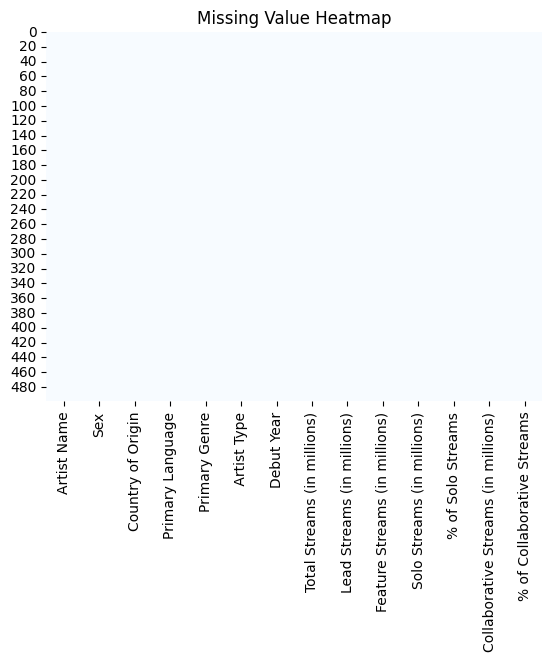

In [11]:
print("\nMissing Values in Each COlumn:\n",df.isnull().sum())
sns.heatmap(df.isnull(),cbar=False, cmap="Blues")
plt.title("Missing Value Heatmap")
plt.show()

for col in ['Sex', 'Country of Origin', 'Primary Language', ' Artist Type']:
    df[col] = df[col].fillna(df[col].mode()[0])

df['Debut Year'] = df['Debut Year'].fillna(df['Debut Year'].median())
df['Feature Streams (in millions)'] = df['Feature Streams (in millions)'].fillna(
    df['Feature Streams (in millions)'].median()
)

In [12]:
initial_rows = df.shape[0]
df.drop_duplicates(inplace=True)
print(f"\nRemoved {initial_rows-df.shape[0]} duplicate rows.")



Removed 0 duplicate rows.


In [13]:
df['Debut Year'] = df['Debut Year'].replace('3+',3).fillna(0).astype(int)
for col in ['Sex', 'Country of Origin', 'Primary Language', ' Artist Type']:
    df[col] = df[col].str.strip().str.capitalize()

In [17]:
min_max_scaler=MinMaxScaler()
scale_cols = ['Debut Year','Total Streams (in millions)','Lead Streams (in millions)']
df[scale_cols]=min_max_scaler.fit_transform(df[scale_cols])
scaler=StandardScaler()
df['solo Streams (in millions)']=scaler.fit_transform(df[['Solo Streams (in millions)']])
print("\nCleaned Data Summary:")
print(df.info())
print(df.head())


Cleaned Data Summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 15 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Artist Name                          500 non-null    object 
 1   Sex                                  500 non-null    object 
 2   Country of Origin                    500 non-null    object 
 3   Primary Language                     500 non-null    object 
 4   Primary Genre                        500 non-null    object 
 5    Artist Type                         500 non-null    object 
 6   Debut Year                           500 non-null    float64
 7   Total Streams (in millions)          500 non-null    float64
 8   Lead Streams (in millions)           500 non-null    float64
 9   Feature Streams (in millions)        500 non-null    float64
 10  Solo Streams (in millions)           500 non-null    float64
 11  % of Solo